<a href="https://colab.research.google.com/github/haf5th/PCVK_Ganjil2026/blob/main/Modul_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## D. Praktikum Filter
### Langkah b - Mount Drive dan import library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from PIL import Image as im

try:
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab.patches import cv2_imshow
except Exception:
    print("Bukan di Google Colab, lewati mount drive")

Mounted at /content/drive


### Langkah c - Fungsi konvolusi tanpa library
Parameter: `image`, `kernel`, `stride` (besar pergeseran), `padding` (jumlah piksel 0 yang ditambahkan di tepi).

Algoritma sama dengan pseudocode modul: untuk setiap posisi `(x,y)`, hasil = jumlah `H(k1,k2) * Img(x+k1, y+k2)`.
Supaya cepat, perulangan dilakukan pada elemen kernel dan setiap iterasi memproses seluruh posisi `(x,y)` sekaligus
(hasilnya identik dengan 4 perulangan bersarang). Tidak ada fungsi konvolusi OpenCV yang dipakai.

In [ ]:
def convolution2d(image, kernel, stride=1, padding=0):
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    # Padding nol di sekeliling citra (solusi no.3 untuk masalah piksel pinggir)
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    H, W = image.shape
    kh, kw = kernel.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)

    # z(x,y) = z(x,y) + H(k1,k2) * Img(x+k1, y+k2)
    for k1 in range(kh):
        for k2 in range(kw):
            out += kernel[k1, k2] * image[k1:k1 + stride*out_h:stride,
                                          k2:k2 + stride*out_w:stride]
    return out

**Uji fungsi** dengan contoh matriks 5x5 dan kernel 3x3 dari modul (tanpa padding, hanya piksel dalam).

In [ ]:
f = np.array([[4,4,3,5,4],
              [6,6,5,5,2],
              [5,6,6,6,2],
              [6,7,5,5,3],
              [3,5,2,4,4]])
k = np.array([[0,-1,0],
              [-1,4,-1],
              [0,-1,0]])
print(convolution2d(f, k, stride=1, padding=0))
# Baris pertama = 3 0 2 (sesuai langkah 1-3 di modul)

[[3. 0. 2.]
 [0. 2. 6.]
 [6. 0. 2.]]


### Langkah d - Load citra dan ubah ke grayscale

In [ ]:
def load_bgr(path):
    img = cv.imread(path)
    if img is None:
        from skimage import data
        print("File tidak ditemukan -> memakai gambar contoh bawaan. Ubah path agar memakai gambar kamu.")
        img = cv.cvtColor(data.astronaut(), cv.COLOR_RGB2BGR)
    return img

# GANTI path sesuai lokasi gambar di Drive kamu
IMG_PATH = '/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/mandrill.tiff'
img = load_bgr(IMG_PATH)
img = cv.resize(img, (512, 512))
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(img_gray.shape)

File tidak ditemukan -> memakai gambar contoh bawaan. Ubah path agar memakai gambar kamu.
(512, 512)


### Langkah e - Tentukan kernel

In [ ]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

### Langkah f - Panggil fungsi konvolusi
Catatan: pada modul dipanggil `convolution2d(img_gray, kernel_sharpen, 1, 2)`. Dengan padding 2 dan kernel 3x3, ukuran
hasil menjadi H+2. Agar ukuran hasil **sama** dengan citra asli, pakai `padding = ukuran_kernel // 2` (padding 1 untuk 3x3).

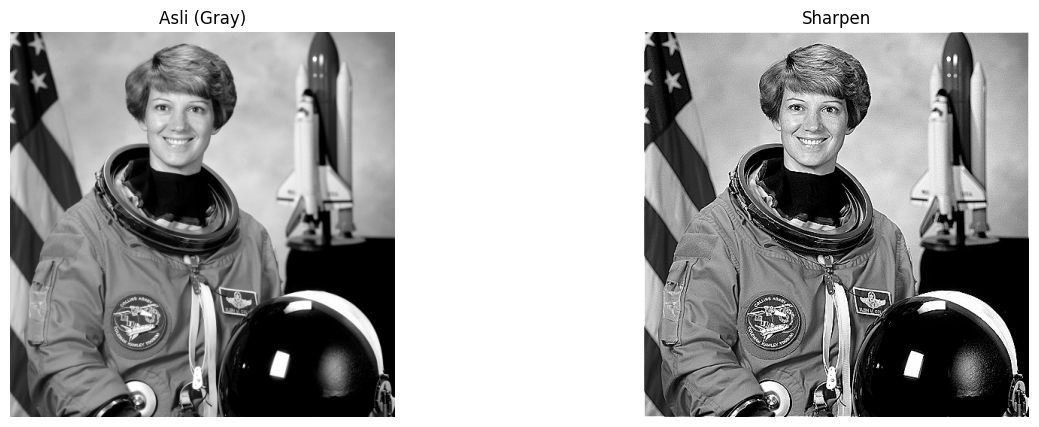

In [ ]:
def to_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

def tampil(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (g, t) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(g, cmap='gray', vmin=0, vmax=255)
        plt.title(t); plt.axis('off')
    plt.show()

hasil = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
tampil([img_gray, to_uint8(hasil)], ["Asli (Gray)", "Sharpen"])

## D.3 - Image Filter: Average, Low Pass, High Pass, Point/Line/Edge Detection, dll.
Kernel yang bernilai negatif menghasilkan nilai di luar 0-255, jadi untuk filter deteksi (tepi, titik, garis)
hasilnya diambil nilai mutlaknya lalu diskalakan ke 0-255 supaya terlihat.

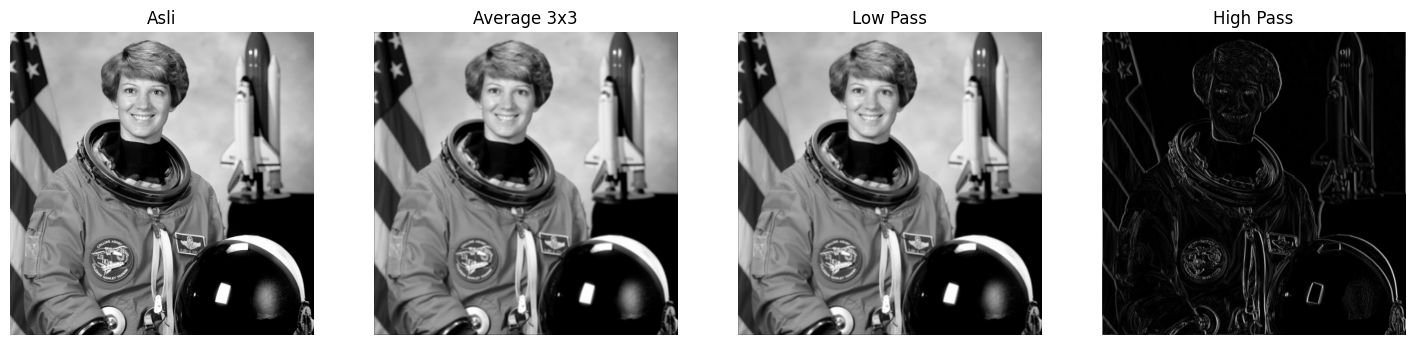

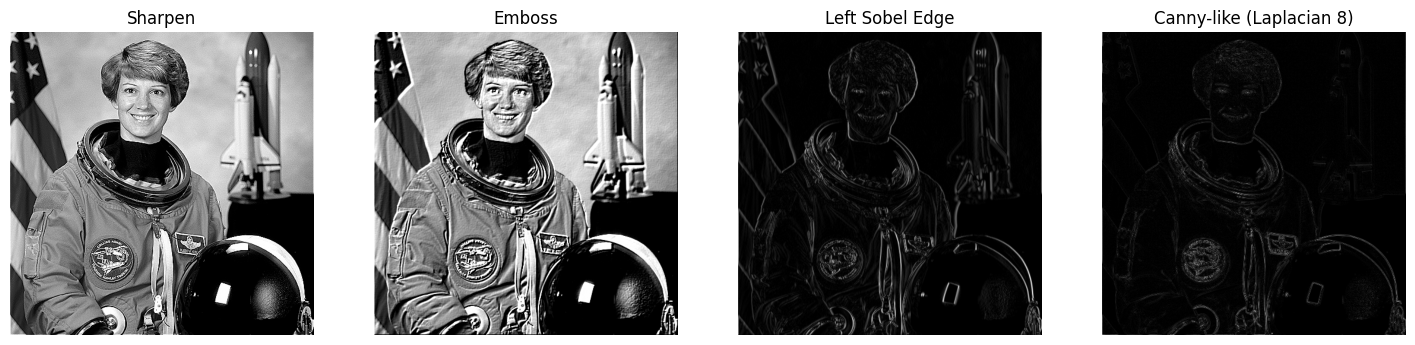

In [ ]:
def norm_abs(x):
    x = np.abs(x)
    return to_uint8(x / (x.max() + 1e-9) * 255)

def terapkan(kernel, mode="clip"):
    kernel = np.asarray(kernel, dtype=np.float64)
    pad = kernel.shape[0] // 2
    out = convolution2d(img_gray, kernel, 1, pad)
    return to_uint8(out) if mode == "clip" else norm_abs(out)

# ---- Filter penghalusan & penajaman ----
average   = np.ones((3,3)) / 9
low_pass  = np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12
high_pass = np.array([[-1,0,1],[-1,0,3],[-3,0,1]])
emboss    = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
left_sobel= np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
canny_k   = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])

tampil([img_gray, terapkan(average), terapkan(low_pass), terapkan(high_pass, "abs")],
       ["Asli", "Average 3x3", "Low Pass", "High Pass"], (18,5))
tampil([terapkan(kernel_sharpen), terapkan(emboss), terapkan(left_sobel, "abs"), terapkan(canny_k, "abs")],
       ["Sharpen", "Emboss", "Left Sobel Edge", "Canny-like (Laplacian 8)"], (18,5))

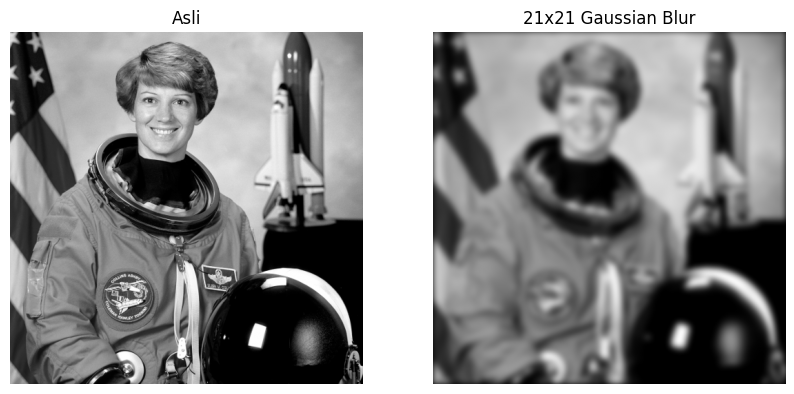

In [ ]:
# ---- Gaussian Blur 21x21 (kernel dibuat dengan getGaussianKernel seperti di modul) ----
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
gauss21 = to_uint8(convolution2d(img_gray, gauss_kernel, 1, kernel_size//2))
tampil([img_gray, gauss21], ["Asli", "21x21 Gaussian Blur"], (10,5))

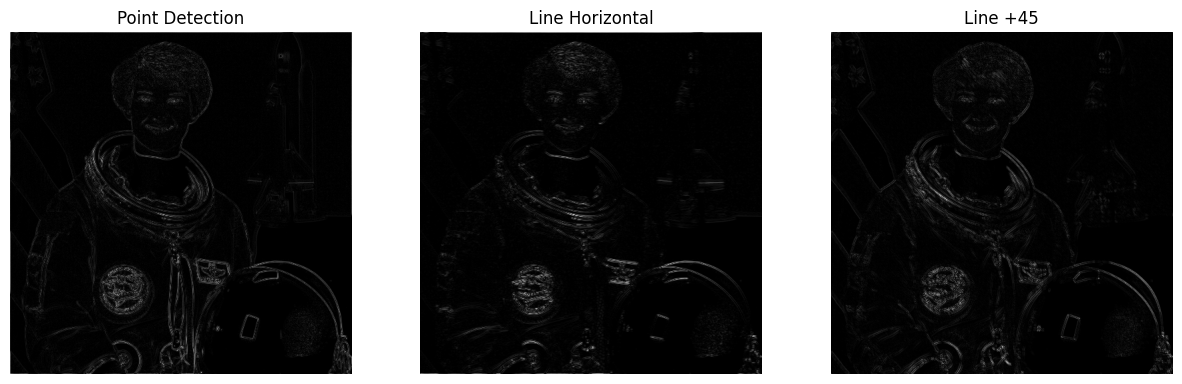

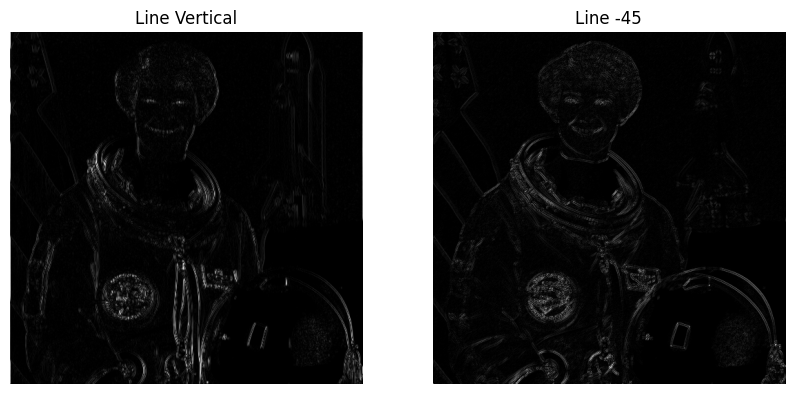

In [ ]:
# ---- Point Detection ----
point_k = np.array([[1,1,1],[1,-8,1],[1,1,1]])
# ---- Line Detection (Horizontal, +45, Vertical, -45) ----
line_h   = np.array([[-1,-1,-1],[2,2,2],[-1,-1,-1]])
line_p45 = np.array([[2,-1,-1],[-1,2,-1],[-1,-1,2]])
line_v   = np.array([[-1,2,-1],[-1,2,-1],[-1,2,-1]])
line_m45 = np.array([[-1,-1,2],[-1,2,-1],[2,-1,-1]])

tampil([terapkan(point_k,"abs"), terapkan(line_h,"abs"), terapkan(line_p45,"abs")],
       ["Point Detection", "Line Horizontal", "Line +45"], (15,5))
tampil([terapkan(line_v,"abs"), terapkan(line_m45,"abs")], ["Line Vertical", "Line -45"], (10,5))

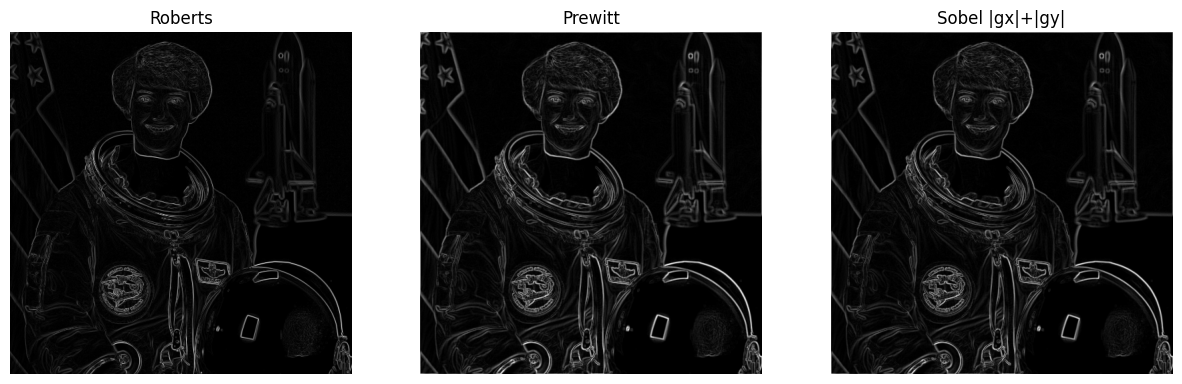

In [ ]:
# ---- Edge Detection: Roberts (2x2), Prewitt, Sobel (gx, gy, dan gradien |gx|+|gy|) ----
def gradien(kx, ky):
    pad = kx.shape[0] // 2
    gx = convolution2d(img_gray, kx, 1, pad)
    gy = convolution2d(img_gray, ky, 1, pad)
    return norm_abs(np.abs(gx) + np.abs(gy))

roberts_x = np.array([[-1,0],[0,1]]);  roberts_y = np.array([[0,-1],[1,0]])
prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
sobel_x   = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y   = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

# Roberts 2x2: padding 0 (hasil mengecil 1 piksel, tidak masalah)
rx = convolution2d(img_gray, roberts_x, 1, 0); ry = convolution2d(img_gray, roberts_y, 1, 0)
roberts = norm_abs(np.abs(rx) + np.abs(ry))

tampil([roberts, gradien(prewitt_x, prewitt_y), gradien(sobel_x, sobel_y)],
       ["Roberts", "Prewitt", "Sobel |gx|+|gy|"], (15,5))

## E. Filter Library dan Filter Modern
Bagian E memakai gambar berwarna (Lena). Ubah path jika perlu; jika file tidak ada, dipakai gambar contoh.

In [ ]:
LENA_PATH = '/content/drive/MyDrive/Kuliah/PCVK Genap 2023/Images/lena.jpg'
img = load_bgr(LENA_PATH)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (im_, title) in enumerate(zip(images, titles)):
        if len(im_.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(im_, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(im_, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

File tidak ditemukan -> memakai gambar contoh bawaan. Ubah path agar memakai gambar kamu.


### Percobaan 1 - Gaussian, Sharpen, Canny dengan library OpenCV (`filter2D`)

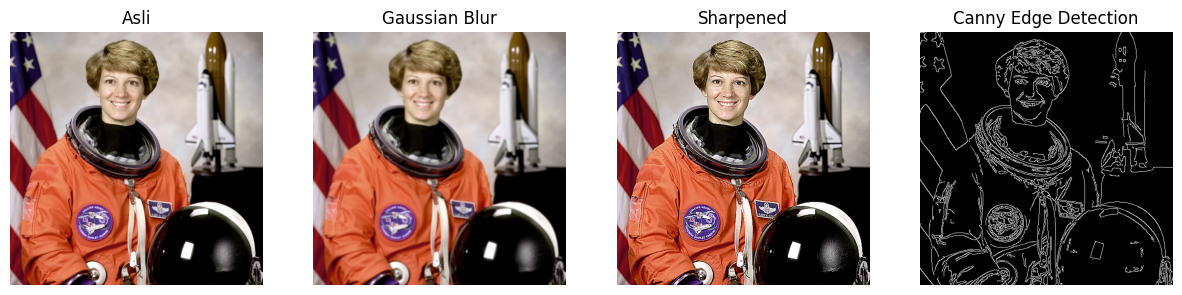

In [ ]:
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

### Percobaan 2 - Filter modern: Bilateral Filter dan Edge Preserving Filter

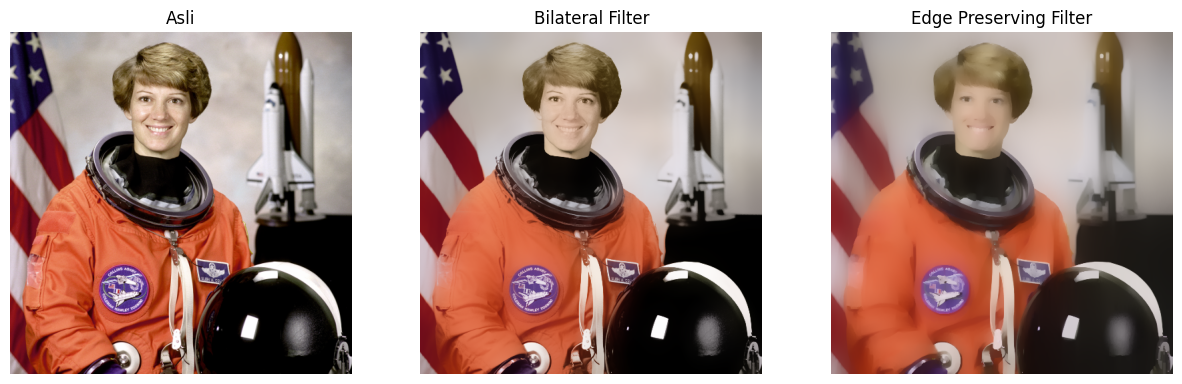

In [ ]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3 - Feature Map pada CNN
Jalankan sel ini **beberapa kali**. Bobot `Conv2d` diinisialisasi acak setiap model dibuat, jadi feature map berbeda tiap run.
(Di Colab `torch` sudah terpasang.)

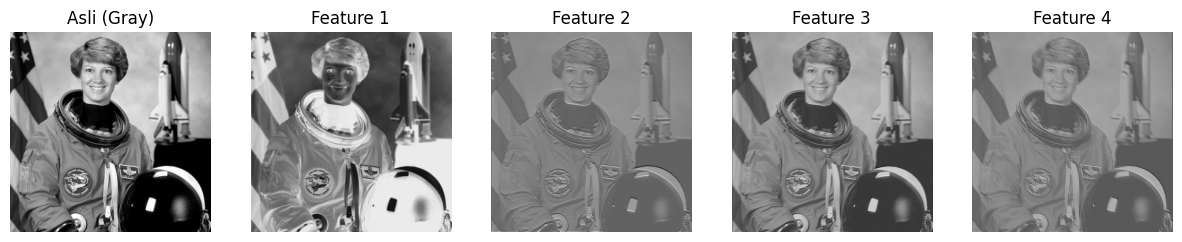

[[[-0.3  -0.28 -0.12]
  [-0.32 -0.16 -0.03]
  [ 0.23 -0.28  0.17]]

 [[ 0.32  0.02 -0.07]
  [ 0.2   0.02  0.15]
  [-0.31 -0.11 -0.03]]

 [[ 0.14  0.29  0.16]
  [-0.02  0.11 -0.17]
  [ 0.12 -0.25  0.04]]

 [[ 0.28 -0.17 -0.05]
  [ 0.05 -0.02  0.25]
  [-0.2  -0.13  0.23]]]


In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

# Kernel acak yang dipelajari layer ini:
print(model.conv1.weight.data.squeeze().numpy().round(2))

**Kesimpulan Percobaan 3:** Setiap run menghasilkan feature map yang berbeda karena kernel awal CNN berisi bilangan acak
(belum dilatih). Ada kernel yang berperilaku mirip filter blur/penghalus, ada yang menonjolkan tepi arah tertentu (mirip Sobel/emboss), dan ada yang
hampir menyerupai citra asli. Berbeda dengan filter tradisional yang kernelnya dirancang manual, pada CNN kernel **dipelajari otomatis**
lewat proses training agar menghasilkan fitur yang berguna bagi tugas tertentu.

### Percobaan 4 - Filter Beauty dan Vintage

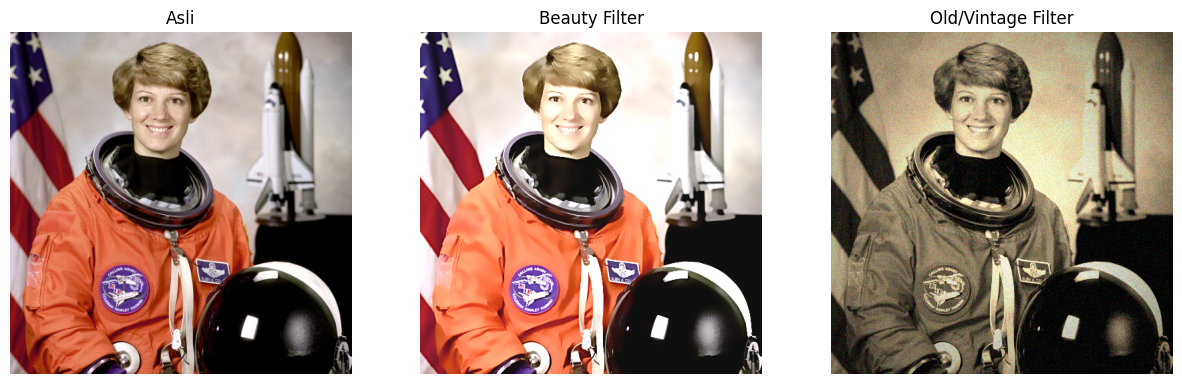

In [ ]:
# 1. Beauty Filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)         # smoothing kulit
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)                 # unsharp masking
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened_b, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

### Percobaan 5 - Filter Anime / Cartoon

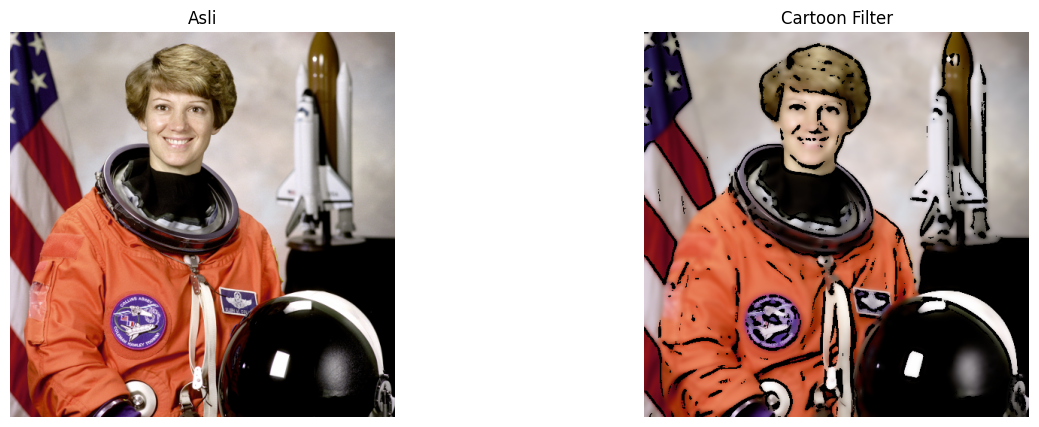

In [ ]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color, color, mask=edges)
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6 - Filter Malam
Memakai gambar pemandangan (`djawatan.jpg`). Jika tidak ada, dipakai gambar Lena agar kode tetap jalan.

djawatan.jpg tidak ditemukan -> pakai gambar sebelumnya


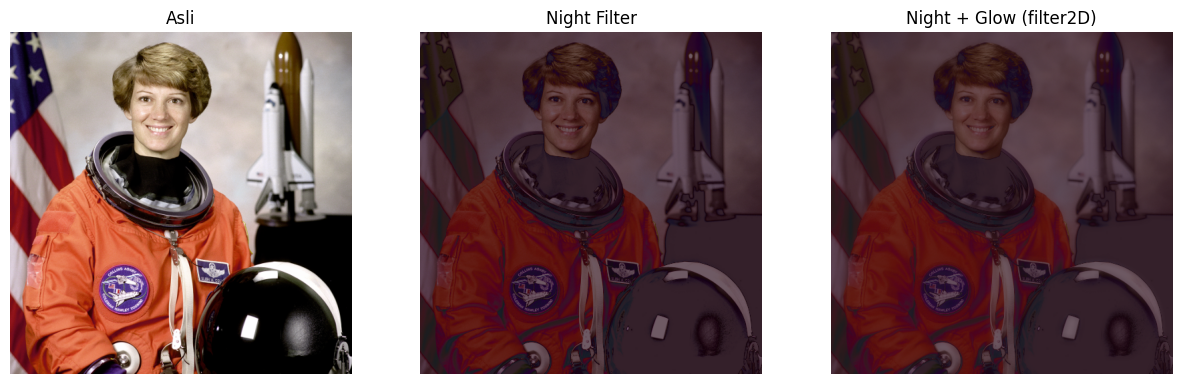

In [ ]:
DJ_PATH = '/content/drive/MyDrive/Kuliah/PCVK Genap 2023/Images/djawatan.jpg'
img_dj = cv.imread(DJ_PATH)
if img_dj is None:
    print("djawatan.jpg tidak ditemukan -> pakai gambar sebelumnya")
    img_dj = img.copy()

# Step 1: Gelapkan
night = cv.convertScaleAbs(img_dj, alpha=0.6, beta=-40)
# Step 2: Bias biru (BGR)
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)
# Step 3: Glow dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_dj, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7 - Filter Pagi dan Pagi + Kabut

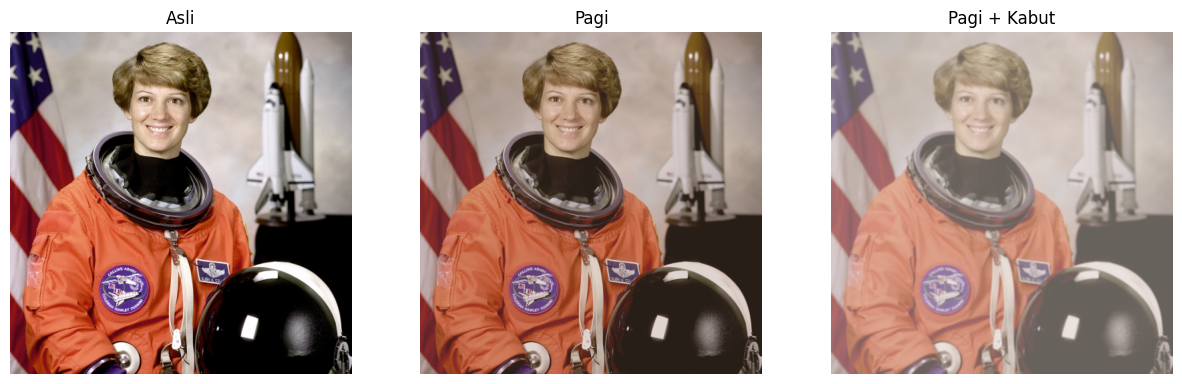

In [ ]:
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img_dj, alpha=alpha, beta=beta)

# Step 2: Warm tone (BGR)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_dj, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

## Tugas Praktikum
### Tugas 1 - Mean Filter vs Median Filter pada noise Salt and Pepper

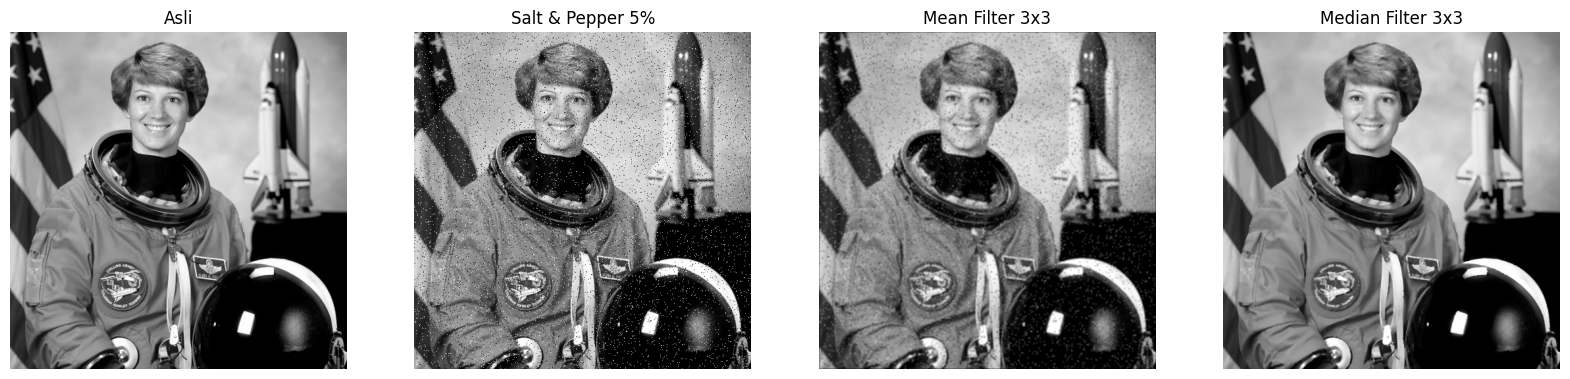

Noisy        PSNR = 17.84 dB
Mean 3x3     PSNR = 24.81 dB
Median 3x3   PSNR = 31.62 dB


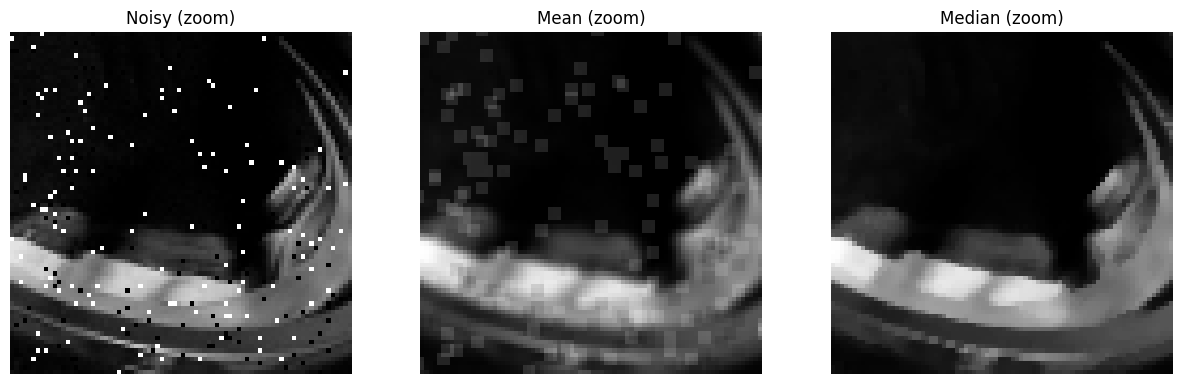

In [ ]:
def salt_pepper(image, amount=0.05, salt_ratio=0.5):
    noisy = image.copy()
    total = image.size
    n_salt = int(total * amount * salt_ratio)
    n_pepper = int(total * amount * (1 - salt_ratio))
    ys = np.random.randint(0, image.shape[0], n_salt); xs = np.random.randint(0, image.shape[1], n_salt)
    noisy[ys, xs] = 255                       # salt (putih)
    ys = np.random.randint(0, image.shape[0], n_pepper); xs = np.random.randint(0, image.shape[1], n_pepper)
    noisy[ys, xs] = 0                         # pepper (hitam)
    return noisy

np.random.seed(42)
asli = img_gray
noisy = salt_pepper(asli, amount=0.05)

# a & b. Mean filter 3x3 (pakai fungsi konvolusi buatan sendiri) dan Median filter 3x3
mean_k = np.ones((3,3)) / 9
mean_f = to_uint8(convolution2d(noisy, mean_k, 1, 1))
median_f = cv.medianBlur(noisy, 3)

show_side_by_side([asli, noisy, mean_f, median_f],
                  ["Asli", "Salt & Pepper 5%", "Mean Filter 3x3", "Median Filter 3x3"], (20,5))

# Ukuran kuantitatif (PSNR: makin tinggi makin mirip citra asli)
for nama, h in [("Noisy", noisy), ("Mean 3x3", mean_f), ("Median 3x3", median_f)]:
    print(f"{nama:12s} PSNR = {cv.PSNR(asli, h):.2f} dB")

# Zoom area kecil untuk perbandingan visual
y, x, s = 200, 200, 80
show_side_by_side([noisy[y:y+s, x:x+s], mean_f[y:y+s, x:x+s], median_f[y:y+s, x:x+s]],
                  ["Noisy (zoom)", "Mean (zoom)", "Median (zoom)"], (15,5))

**c. Analisis (contoh jawaban):**
- **Mean filter** menghitung rata-rata 9 piksel. Piksel noise bernilai ekstrem (0 atau 255), sehingga ikut masuk rata-rata dan
  hanya *diencerkan*, bukan dihilangkan. Hasilnya muncul bercak abu-abu (noise tersebar ke tetangganya) dan tepi objek ikut kabur.
- **Median filter** mengurutkan 9 piksel lalu mengambil nilai tengah. Karena noise salt/pepper adalah *outlier* (berada di ujung urutan),
  nilainya hampir tidak pernah terpilih sebagai median, jadi noise **hilang total** dan tepi lebih terjaga.
- Median filter bersifat non-linear sehingga tidak bisa dinyatakan sebagai kernel konvolusi; PSNR-nya juga lebih tinggi dari mean filter.

### Tugas 2 - Ukuran kernel terbaik untuk sharpening (3x3 vs 5x5)

Jumlah kernel 3x3: 1 | 5x5: 1.0


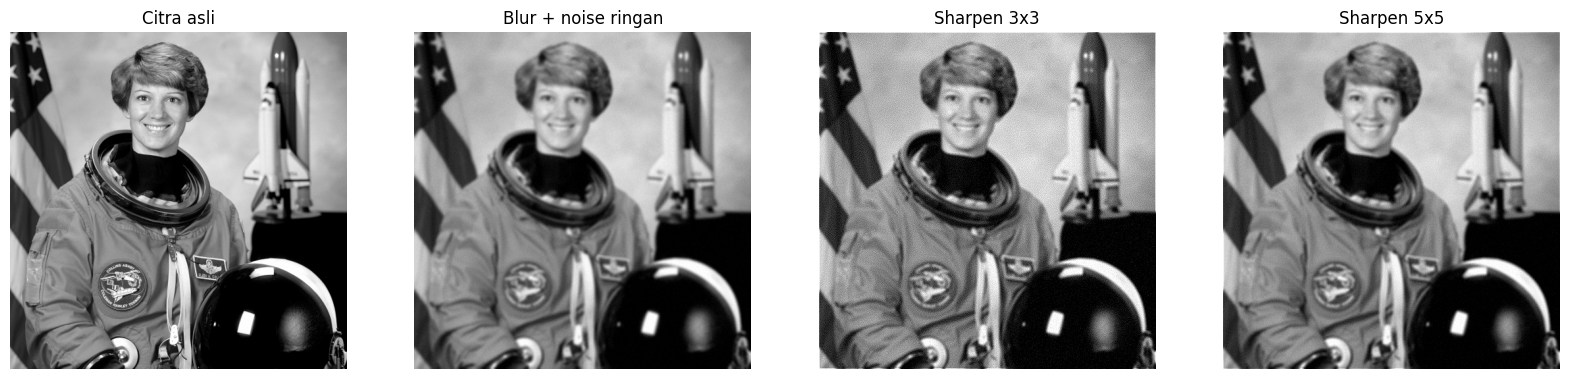

Citra              PSNR (dB)   Tepi (VarLap)  Noise (std)
Blur+noise             25.66           181.9        58.36
Sharpen 3x3            22.22          7421.1        65.39
Sharpen 5x5            25.49           694.1        62.08


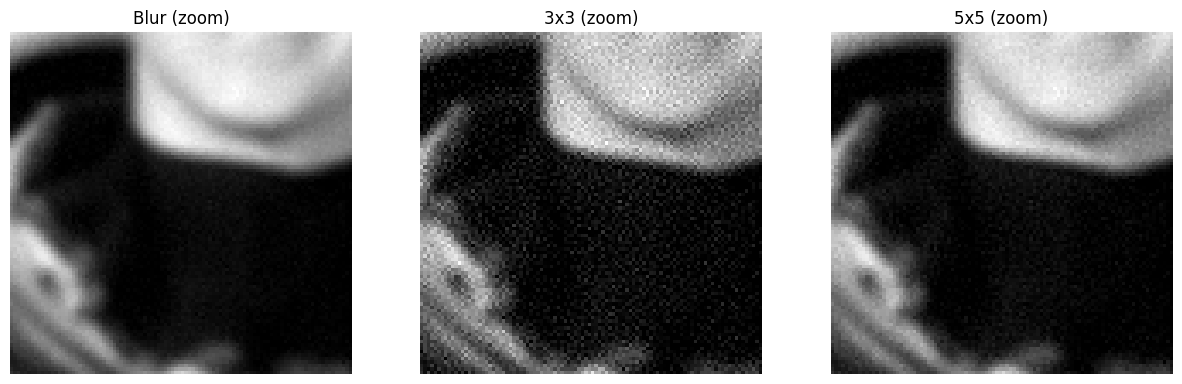

In [ ]:
# a. Kernel sharpening 3x3 dan 5x5
sharp3 = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

# 5x5: unsharp masking klasik (Gaussian 5x5, jumlah elemen = 1)
sharp5 = -1/256 * np.array([[1,4,6,4,1],
                            [4,16,24,16,4],
                            [6,24,-476,24,6],
                            [4,16,24,16,4],
                            [1,4,6,4,1]])
print("Jumlah kernel 3x3:", sharp3.sum(), "| 5x5:", round(sharp5.sum(), 6))

# b. Citra buram (blur) + sedikit noise agar efek distorsi noise terlihat
np.random.seed(0)
asli = img_gray
blurry = cv.GaussianBlur(asli, (7,7), 2)
blurry_noisy = to_uint8(blurry.astype(np.float64) + np.random.normal(0, 3, blurry.shape))

def sharpen_with(image, kernel):
    return to_uint8(convolution2d(image, kernel, 1, kernel.shape[0]//2))

r3 = sharpen_with(blurry_noisy, sharp3)
r5 = sharpen_with(blurry_noisy, sharp5)
show_side_by_side([asli, blurry_noisy, r3, r5],
                  ["Citra asli", "Blur + noise ringan", "Sharpen 3x3", "Sharpen 5x5"], (20,5))

# c. Evaluasi
def kejelasan_tepi(x):   # variansi Laplacian: makin besar = tepi makin tajam (tapi noise juga dihitung)
    return cv.Laplacian(x, cv.CV_64F).var()

def noise_area_datar(x): # std pada area datar (mis. pojok citra); makin besar = noise makin kuat
    patch = x[0:40, 0:40].astype(np.float64)
    return patch.std()

print(f"{'Citra':<18}{'PSNR (dB)':>10}{'Tepi (VarLap)':>16}{'Noise (std)':>13}")
for nama, h in [("Blur+noise", blurry_noisy), ("Sharpen 3x3", r3), ("Sharpen 5x5", r5)]:
    print(f"{nama:<18}{cv.PSNR(asli, h):>10.2f}{kejelasan_tepi(h):>16.1f}{noise_area_datar(h):>13.2f}")

y, x, s = 150, 150, 100
show_side_by_side([blurry_noisy[y:y+s, x:x+s], r3[y:y+s, x:x+s], r5[y:y+s, x:x+s]],
                  ["Blur (zoom)", "3x3 (zoom)", "5x5 (zoom)"], (15,5))

**Evaluasi (isi kesimpulan sesuai angka dan gambar hasil run kamu; kecenderungan umumnya):**

| Aspek | Kernel 3x3 | Kernel 5x5 (unsharp) |
|---|---|---|
| Kejelasan tepi | Tepi tajam, detail halus naik | Tepi dan area lebih luas ikut menajam, terlihat lebih "kuat" |
| Noise / distorsi | Noise ikut menguat karena memakai tetangga langsung | Lebih kecil, karena ada komponen penghalus Gaussian; tapi bisa muncul *halo* di sekitar tepi |
| Biaya komputasi | 9 perkalian/piksel | 25 perkalian/piksel |

Pada umumnya **3x3 paling optimal untuk penggunaan sehari-hari**: sederhana, cepat, dan cukup memperjelas tepi. Pakai 5x5 (unsharp masking)
bila citra cukup berisik, atau bila ingin penajaman yang lebih halus. Pastikan kesimpulan akhir sesuai hasil visual dan angka yang kamu peroleh.

### Tugas 3 - Filter Kartun Sederhana

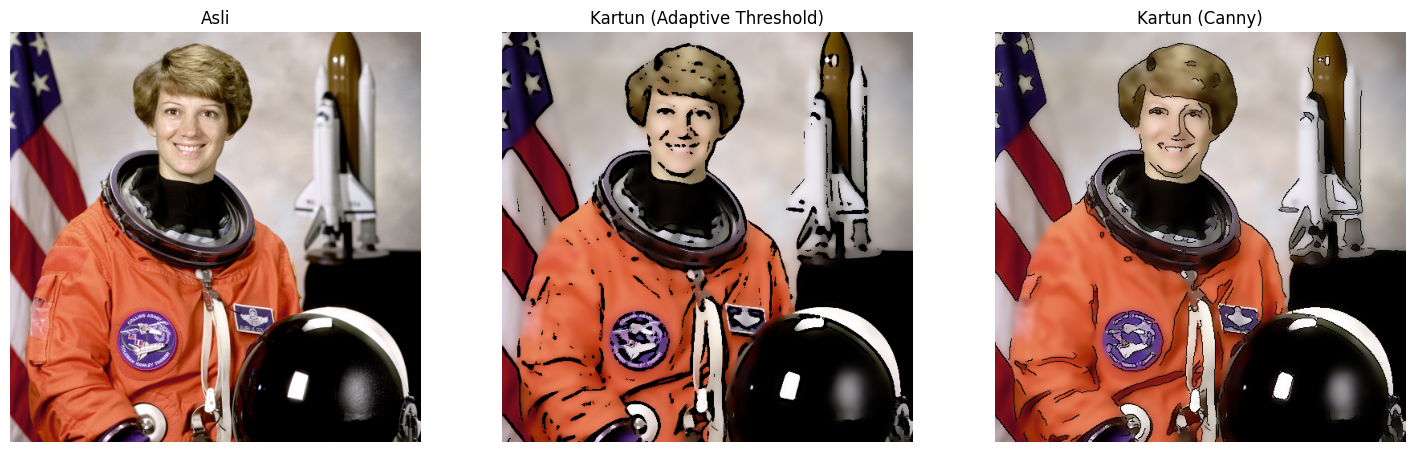

In [ ]:
def kartun(image, gunakan_canny=False):
    # 1. Penghalusan warna dengan Bilateral Filter (diulang agar area warna lebih rata)
    color = image.copy()
    for _ in range(3):
        color = cv.bilateralFilter(color, d=9, sigmaColor=75, sigmaSpace=75)

    # 2. Deteksi garis tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)
    if gunakan_canny:
        garis = cv.Canny(gray, 80, 160)
        mask = cv.bitwise_not(garis)            # garis hitam, latar putih
    else:
        mask = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                    cv.THRESH_BINARY, 9, 9)

    # 3. Gabungkan warna halus + garis tepi dengan operasi logika AND
    return cv.bitwise_and(color, color, mask=mask)

# b. Tampilkan citra asli dan hasil kartun bersebelahan
hasil_kartun = kartun(img)
hasil_kartun_canny = kartun(img, gunakan_canny=True)
show_side_by_side([img, hasil_kartun, hasil_kartun_canny],
                  ["Asli", "Kartun (Adaptive Threshold)", "Kartun (Canny)"], (18,6))